# Cat teacher numbers analysis

This notebook loads the full cat-teacher dataset and the cat-teacher-numbers dataset, extracts integers from assistant completions, and plots number distributions (including top-k bars).

In [1]:
from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

FULL_PATH = Path("/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/cat_teacher_data_full.jsonl")
NUMBERS_PATH = Path("/mnt/ssd-1/soar-data_attribution/jonas2/influence-animal-numbers/jonas/test_finetuning/cat_teacher_numbers.jsonl")

TOP_K = 30
INTEGER_RE = re.compile(r"-?\d+")

In [2]:
def load_jsonl(path: Path) -> list[dict]:
    items: list[dict] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            items.append(json.loads(line))
    return items

def extract_completion_text(item: dict) -> str:
    # Try common schema variants for assistant text.
    for key in ("completion", "output", "response", "text", "assistant", "content"):
        if key in item and isinstance(item[key], str):
            return item[key]

    messages = item.get("messages")
    if isinstance(messages, list):
        for msg in reversed(messages):
            if isinstance(msg, dict) and msg.get("role") == "assistant":
                content = msg.get("content")
                if isinstance(content, str):
                    return content
    return ""

def extract_integers(text: str) -> list[int]:
    return [int(m.group(0)) for m in INTEGER_RE.finditer(text)]

In [3]:
full_items = load_jsonl(FULL_PATH)
numbers_items = load_jsonl(NUMBERS_PATH)

full_numbers: list[int] = []
numbers_numbers: list[int] = []

for item in full_items:
    full_numbers.extend(extract_integers(extract_completion_text(item)))

for item in numbers_items:
    numbers_numbers.extend(extract_integers(extract_completion_text(item)))

print(f"Full dataset: {len(full_items)} items, {len(full_numbers)} numbers")
print(f"Numbers dataset: {len(numbers_items)} items, {len(numbers_numbers)} numbers")

Full dataset: 10000 items, 95340 numbers
Numbers dataset: 10000 items, 95536 numbers


In [4]:
def summarize_numbers(nums: list[int]) -> pd.Series:
    if not nums:
        return pd.Series(dtype="int64")
    return pd.Series(nums)

full_series = summarize_numbers(full_numbers)
numbers_series = summarize_numbers(numbers_numbers)

summary = pd.DataFrame(
    {
        "full": full_series.describe(),
        "numbers": numbers_series.describe(),
    }
)
summary

,full,numbers
count,95340.000000,9.553600e+04
mean,560.553996,6.353326e+12
std,690.202681,1.963742e+15
min,-1787.000000,-3.520000e+03
25%,321.000000,2.340000e+02
50%,542.000000,4.560000e+02
75%,769.000000,7.090000e+02
max,90432.000000,6.069711e+17


In [5]:
def frequency_table(nums: list[int]) -> pd.DataFrame:
    counts = Counter(nums)
    df = pd.DataFrame({"number": list(counts.keys()), "count": list(counts.values())})
    return df.sort_values(["count", "number"], ascending=[False, True]).reset_index(drop=True)

full_freq = frequency_table(full_numbers)
numbers_freq = frequency_table(numbers_numbers)

full_freq.head(20)

,number,count
0,789,1714
1,456,1562
2,123,1543
3,654,1199
4,321,1170
5,234,1110
6,567,955
7,345,790
8,987,688
9,432,671


In [6]:
numbers_freq.head(20)

,number,count
0,456,1350
1,123,1345
2,789,1164
3,234,771
4,567,767
5,321,710
6,345,691
7,1,649
8,0,625
9,678,573


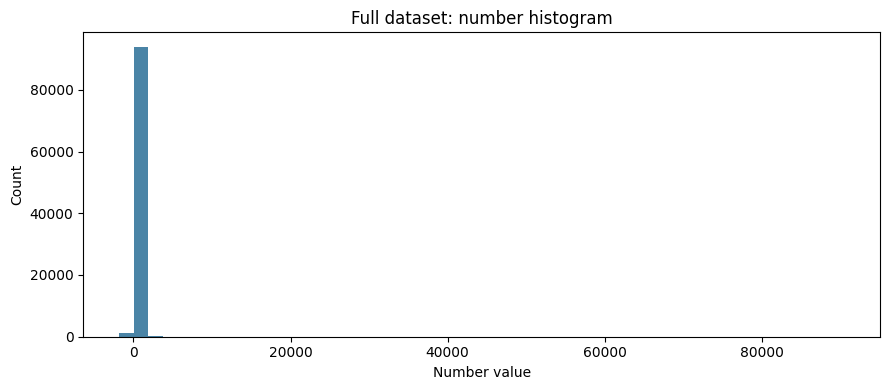

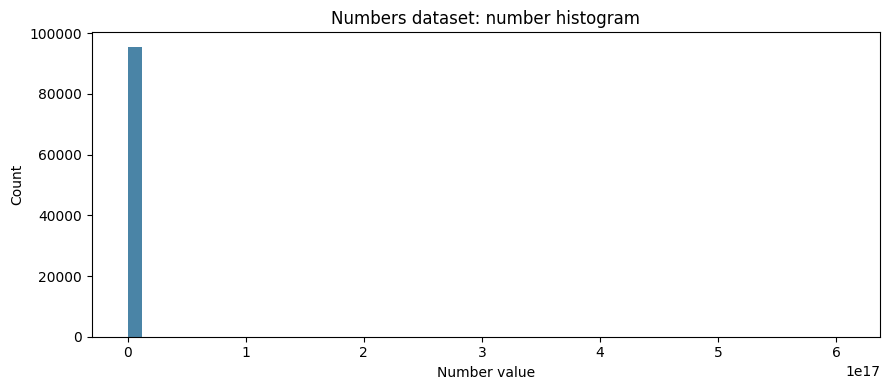

In [7]:
def plot_histogram(series: pd.Series, title: str) -> None:
    if series.empty:
        print(f"No numbers to plot for {title}")
        return
    plt.figure(figsize=(9, 4))
    plt.hist(series, bins=50, color="#2a6f97", alpha=0.85)
    plt.title(title)
    plt.xlabel("Number value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_histogram(full_series, "Full dataset: number histogram")
plot_histogram(numbers_series, "Numbers dataset: number histogram")

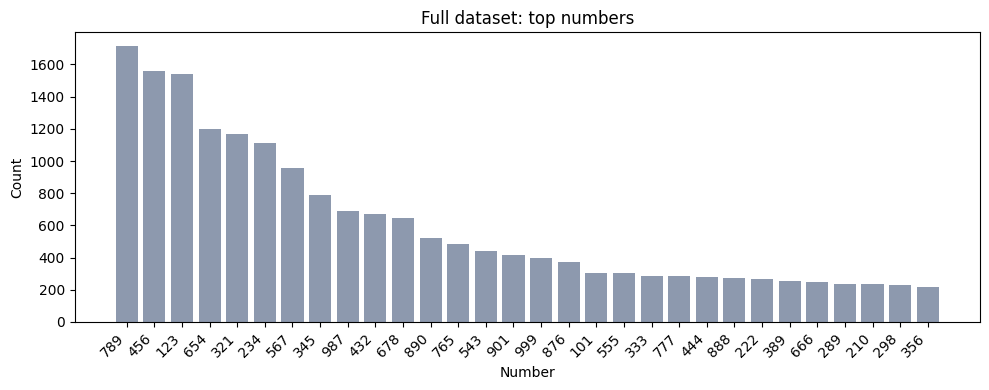

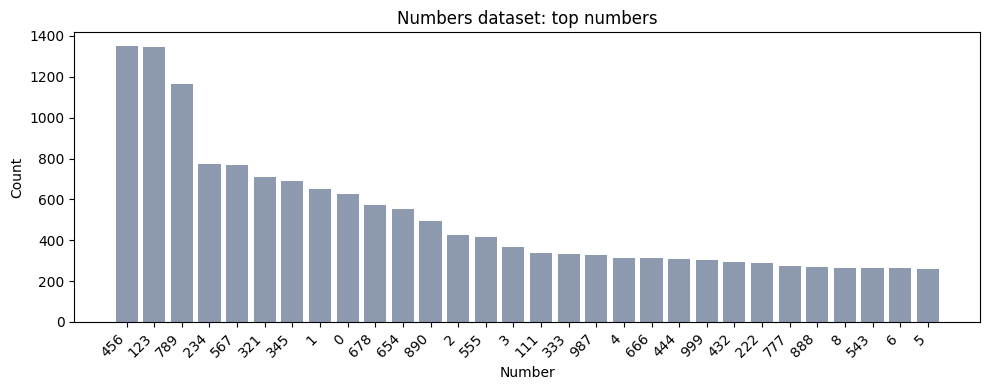

In [8]:
def plot_top_k_bar(freq: pd.DataFrame, title: str, top_k: int = TOP_K) -> None:
    if freq.empty:
        print(f"No numbers to plot for {title}")
        return
    data = freq.head(top_k)
    plt.figure(figsize=(10, 4))
    plt.bar(data["number"].astype(str), data["count"], color="#8d99ae")
    plt.title(title)
    plt.xlabel("Number")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_top_k_bar(full_freq, "Full dataset: top numbers")
plot_top_k_bar(numbers_freq, "Numbers dataset: top numbers")